# How does sales split into customers, orders per customer and order value, each a fraction on one definition?

**Week 1, Monday, chapter 2 of 6.** Meera asked what sales is made of, and the answer is a tree:
revenue is customers, times orders per customer, times average order value, and order value is
items per order times price per item, less discounts.

**Who needs the answer.** Meera needs the tree to see which branch of sales is short, and the
marketing lead's payback case values every new customer by the order they will place, so it
leans on the order-value branch. A branch helps them only when it is a metric, a numerator over
a denominator on one definition and one window. A branch built from two definitions multiplies
back to revenue nobody booked, and a budget sized on it is too large.

**The questions on the way.**

1. Which revenue tree can this file fill?
2. What is Kalpa's average order value on booked orders?
3. What goes wrong when booked rupees are divided by delivered orders?
4. Does the mean of the 30 amounts give the same average order value?
5. Which branches does the file still lack?

The metric at stake is average order value (AOV), revenue over orders, the first branch this
file can measure. Reliance reported Jio's quarter as its branches, 533 million subscribers and
revenue per user of Rs 215.6 a month (Reliance Industries media release, 17 July 2026): a
telecom's tree is customers times revenue per customer, stated the same way as Kalpa's.
Section 5 of the retail dossier, `study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers the
metric tree, AOV and basket size.

Chapter 1 settled the readings of sales on the 30 orders: Rs 5,44,810 booked, Rs 5,35,760 not
cancelled on 26 orders and Rs 5,20,790 delivered on 21, each with its name beside it. This
chapter splits the booked total into the tree's branches.

> **Kavya's review.** Give me each branch as a numerator over a denominator, and tell me which
> ones this file cannot fill, because nobody can plan on those yet.

**Setup.** The first cell finds the shared helper, loads the 30 orders from `../data/`, and
turns every amount into a whole number with `int()`, the fix chapter 1 found for an amount
stored as text.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix for an amount stored as text
print(len(ORDERS), "orders loaded, every amount a whole number")

30 orders loaded, every amount a whole number


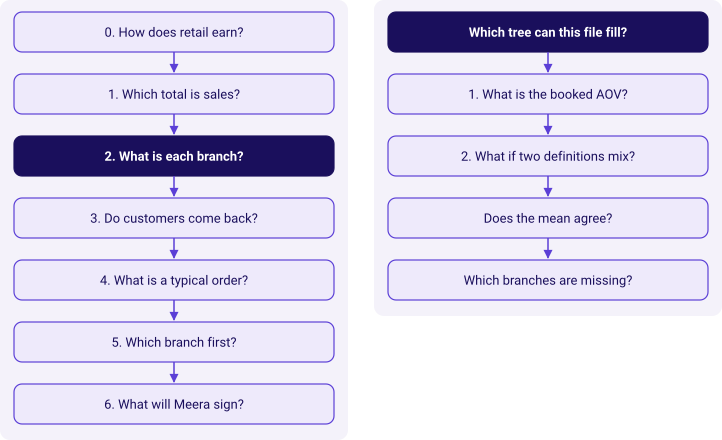

In [2]:
kit.side_by_side(
    kit.vflow(['0. How does retail earn?', '1. Which total is sales?', '2. What is each branch?', '3. Do customers come back?', '4. What is a typical order?', '5. Which branch first?', '6. What will Meera sign?'], lit=2, show=False),
    kit.vflow(['Which tree can this file fill?', '1. What is the booked AOV?', '2. What if two definitions mix?', 'Does the mean agree?', 'Which branches are missing?'], lit=0, show=False),
)

## Which revenue tree can this file fill?

Which tree to draw depends on which fields the file holds.

| Option | Fields it needs | In this file? | What it can tell Meera |
|---|---|---|---|
| A. Revenue = orders x AOV | amount, one row per order | yes | It tells her the size of orders and nothing about who buys. |
| B. Revenue = customers x orders per customer x AOV | amount, customer id | yes | It tells her who buys, how often, and for how much. |
| C. B, with AOV split into items x price, less discounts | items, list price, discount per order | no | It would tell her which part of the basket moved. |
| D. A funnel, visits to orders | sessions or footfall | no | It would tell her where shoppers drop out before buying. |

Each option is sized on this file by setting the fields it needs against the fields the file
holds.

In [3]:
fields = set(ORDERS[0])
needed = {"A": {"amount"}, "B": {"amount", "customer_id"},
          "C": {"amount", "customer_id", "items", "price", "discount"},
          "D": {"sessions", "amount"}}
kit.table(["option", "fields needed", "missing from this file"],
          [(k, ", ".join(sorted(v)), ", ".join(sorted(v - fields)) or "none") for k, v in needed.items()],
          caption="Each tree's fields against the file's " + str(len(fields)))
fillable = [k for k, v in needed.items() if v <= fields]
kit.check("options A and B are the ones this file can fill", fillable == ["A", "B"], fillable)

option,fields needed,missing from this file
A,amount,none
B,"amount, customer_id",none
C,"amount, customer_id, discount, items, price","discount, items, price"
D,"amount, sessions",sessions


**The best-fit call.** B, since it is the deepest tree this file fills and it puts marketing's
branch, customers, beside the two it competes with; C and D each need fields the file does not
hold. **What would change it:** order lines with items and prices (the order-items table
arrives later in the programme) move the call to C, and traffic data would add D in front.

## 1. What is Kalpa's average order value on booked orders?

Average order value is booked revenue over the orders it was summed from. The tree multiplies
the branches back together, and the product has to land on the revenue it started from.

**Predict before you run.** Booked revenue is split into orders times AOV. What does
multiplying the two back together give?

- a) Exactly booked revenue, because the average was made from that total.
- b) More than booked revenue, because repeat customers count twice.
- c) Less than booked revenue, because the average rounds down.
- d) Nothing useful until prices per item are known.

branch,numerator,denominator,in this file
customers,distinct customer ids,"none, it is a count",chapter 3 counts it
orders per customer,orders,distinct customers,chapter 3
average order value,revenue,orders,"Rs 18,160"
items per order,items sold,orders,not in this file
price per item,revenue before discounts,items sold,not in this file
discount rate,rupees discounted,revenue before discounts,not in this file


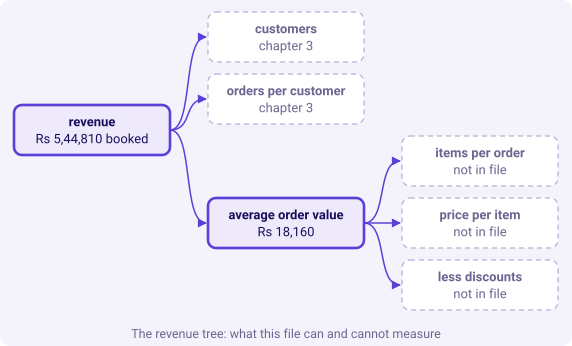

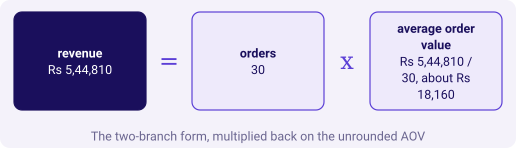

In [4]:
orders = len(ORDERS)
revenue = sum(order["amount"] for order in ORDERS)
aov = revenue / orders
kit.table(["branch", "numerator", "denominator", "in this file"],
          [("customers", "distinct customer ids", "none, it is a count", "chapter 3 counts it"),
           ("orders per customer", "orders", "distinct customers", "chapter 3"),
           ("average order value", "revenue", "orders", kit.rupees(aov)),
           ("items per order", "items sold", "orders", "not in this file"),
           ("price per item", "revenue before discounts", "items sold", "not in this file"),
           ("discount rate", "rupees discounted", "revenue before discounts", "not in this file")],
          caption="Every branch as a metric, booked definition, 1 July to 26 September")
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue) + " booked", "kind": "known", "children": [
    {"label": "customers", "note": "chapter 3", "kind": "unknown"},
    {"label": "orders per customer", "note": "chapter 3", "kind": "unknown"},
    {"label": "average order value", "note": kit.rupees(aov), "kind": "known", "children": [
        {"label": "items per order", "note": "not in file", "kind": "unknown"},
        {"label": "price per item", "note": "not in file", "kind": "unknown"},
        {"label": "less discounts", "note": "not in file", "kind": "unknown"}]}]},
    title="The revenue tree: what this file can and cannot measure")
kit.equation(["revenue\n" + kit.rupees(round(orders * aov)), "=", f"orders\n{orders}", "x",
              "average order value\nRs 5,44,810 / 30, about " + kit.rupees(aov)],
             title="The two-branch form, multiplied back on the unrounded AOV")

In [5]:
kit.check("orders x AOV lands on booked revenue", round(orders * aov) == revenue, kit.rupees(orders * aov))
kit.check("booked AOV is Rs 18,160", round(aov) == 18160, kit.rupees(aov))
missing = [b for b in ("items", "price", "discount") if b not in ORDERS[0]]
kit.check("three branches of six are not in this file", len(missing) == 3, missing)

**What happened.** The answer is a. Kalpa's booked AOV is Rs 5,44,810 over 30 orders, about
Rs 18,160, and 30 times the unrounded AOV, 30 x (Rs 5,44,810 / 30), lands back on the booked
total. Because the product always lands on revenue, a wrong leaf can hide in the split while
the total looks right. Whether Rs 18,160 describes an order anyone would recognise is chapter
4's question.

## 2. What goes wrong when booked rupees are divided by delivered orders?

Finance's report carries booked revenue, and the operations dashboard counts delivered orders,
because delivery is what operations runs. An analyst in a hurry takes one number from each.

**Predict before you run.** Booked rupees over delivered orders gives what AOV?

- a) Rs 18,160, the same as before.
- b) Rs 24,800, the delivered AOV.
- c) Rs 25,943.
- d) Rs 23,687.

**The plausible wrong answer.**

In [6]:
delivered_orders = sum(1 for order in ORDERS if order["status"] == "delivered")
delivered_revenue = sum(order["amount"] for order in ORDERS if order["status"] == "delivered")
hurried_aov = revenue / delivered_orders
print("AOV:", kit.rupees(hurried_aov), "(booked revenue / delivered orders)")
print("The tree then multiplies to:", kit.rupees(orders * hurried_aov), "on", orders, "orders")

AOV: Rs 25,943 (booked revenue / delivered orders)
The tree then multiplies to: Rs 7,78,300 on 30 orders


**Why it is wrong.** The numerator counts the rupees of the 9 cancelled and returned orders while
the denominator has dropped those orders, so every order looks Rs 7,783 larger than a booked
order averages. Multiplied back through the tree on the 30 orders the rupees came from, it
claims Rs 7,78,300 of revenue, 43 percent more than anyone booked, and marketing's payback case
would value a new customer's order on it. The check is the tree's own identity: AOV times the
orders the revenue was summed over must give that revenue back. Multiplying by the 21 delivered
orders would only hand back the numerator, so the check uses the 30 the booked rupees came from.

numerator / denominator,"AOV, rounded",unrounded AOV x the orders the revenue covers,lands on that revenue?
booked / booked,"Rs 18,160","Rs 5,44,810",yes
delivered / delivered,"Rs 24,800","Rs 5,20,790",yes
"booked / delivered, the trap","Rs 25,943","Rs 7,78,300","no, Rs 2,33,490 over"


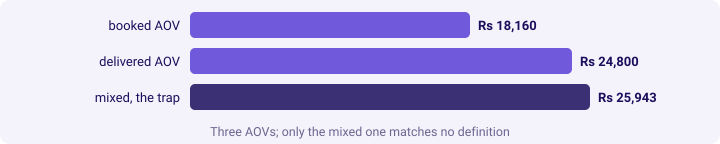

In [7]:
# each fraction, and the orders its revenue was summed over
rows = [("booked / booked", revenue, orders, orders),
        ("delivered / delivered", delivered_revenue, delivered_orders, delivered_orders),
        ("booked / delivered, the trap", revenue, delivered_orders, orders)]
kit.table(["numerator / denominator", "AOV, rounded", "unrounded AOV x the orders the revenue covers",
           "lands on that revenue?"],
          [(n, kit.rupees(round(r / o)), kit.rupees(round(base * r / o)),
            "yes" if round(base * r / o) == r else "no, " + kit.rupees(round(base * r / o - r)) + " over")
           for n, r, o, base in rows], caption="The identity check: AOV times the orders the revenue was summed over")
kit.bars([("booked AOV", round(aov)), ("delivered AOV", round(delivered_revenue / delivered_orders)),
          ("mixed, the trap", round(hurried_aov))], fmt=kit.rupees, lit=(2,),
         title="Three AOVs; only the mixed one matches no definition")
kit.check("the mixed AOV is Rs 25,943", round(hurried_aov) == 25943)
kit.check("multiplied back on 30 orders, the mix claims revenue nobody booked",
          round(orders * hurried_aov) != revenue, kit.rupees(orders * hurried_aov))

**What happened.** The answer is c: booked rupees over delivered orders gives Rs 25,943, which
matches no definition and multiplies back to Rs 7,78,300, 30 x (Rs 5,44,810 / 21). The fix is one
definition per
fraction: booked AOV is Rs 18,160 on 30 orders and delivered AOV is Rs 24,800 on 21 orders, each
goes out with its definition, the tree multiplies back on each, and the mixed Rs 25,943 is
dropped.

## Does the mean of the 30 amounts give the same average order value?

Revenue over orders is the mean of the 30 amounts, so the list's own mean must give the same
number. `statistics.fmean` is the standard library's mean of a list of numbers.

In [8]:
amounts = [order["amount"] for order in ORDERS]
mean_route = sum(amounts) / len(amounts)
import statistics
library_route = statistics.fmean(amounts)
kit.table(["route", "booked AOV"],
          [("revenue / orders", kit.rupees(aov)), ("sum of the list / its length", kit.rupees(mean_route)),
           ("statistics.fmean(amounts)", kit.rupees(library_route))],
          caption="Three routes to one AOV")
kit.check("revenue / orders equals the mean of the amounts", abs(aov - mean_route) < 1e-9)
kit.check("the library's mean agrees", abs(aov - library_route) < 1e-9)

route,booked AOV
revenue / orders,"Rs 18,160"
sum of the list / its length,"Rs 18,160"
statistics.fmean(amounts),"Rs 18,160"


**What happened.** It does: revenue over orders, the list's sum over its length and
`statistics.fmean` all give Rs 18,160.

**When to switch.** Revenue over orders is the route when the totals already exist in a report,
and the mean of the list is the route when you hold the rows; `statistics.fmean` does the same
sum in one line. Chapter 4 makes a bigger switch: when the question is what a typical order
looks like, the mean may be the wrong middle altogether.

> **Kavya's review.** When two reports feed one fraction, ask each report what it counts before
> you divide. The identity check costs one line and would have caught this before Meera saw it.

### How would you answer an interviewer who asks how to grow an online retailer's sales?

**[S] How would you increase sales for an online retailer?** "I would draw the revenue tree
before suggesting anything: customers, times orders per customer, times average order value,
with order value split into items, price and discounts. Then I measure each branch on the same
window and definition and ask which is short against plan, because each costs something
different to move: acquisition costs marketing, frequency costs retention, basket costs
merchandising, and price risks volume. Initiatives come last, each placed on the branch it
moves."

**[F] A business says "grow revenue 15 percent"; how do you turn that into questions data can
answer?** "I ask fifteen percent of which revenue, over which window and against which base.
Then I break the target down the tree and ask what each branch would have to do alone, in customers, orders
and rupees per order. Each is a fraction I can compute and each maps to a team that owns it."

### Why do the denominators cancel when the branches multiply?

Customers x (orders / customers) x (revenue / orders) = revenue, because each denominator
cancels the next numerator. A branch measured on another definition breaks the chain for the
same reason: its denominator no longer matches its neighbour's numerator.

## Which branches does the file still lack?

Three of the tree's six branches are missing: items per order, price per item and discounts
need order lines with items and prices, which arrive later in the programme. The two customer
branches can be counted from the customer ids, which is chapter 3's work.

- Which tree can this file fill? Option B fills: revenue is customers x orders per customer x
  AOV.
- What is the booked AOV? It is Rs 18,160, Rs 5,44,810 over 30 orders.
- What goes wrong when booked rupees meet delivered orders? A mixed AOV of Rs 25,943 claims
  Rs 7,78,300 of revenue that nobody booked.
- Does the mean of the amounts agree? It does, at Rs 18,160 by every route.
- How does sales split? It splits into customers, orders per customer and order value, each a
  fraction on one definition, with three of order value's branches still missing from the file.

What we now know,The evidence
Each branch is a numerator over a denominator on one definition,"AOV = Rs 5,44,810 / 30, about Rs 18,160"
Three branches are not in this file,"items, price and discounts"
A fraction from two definitions matches nothing,"Rs 25,943 would claim Rs 7,78,300"


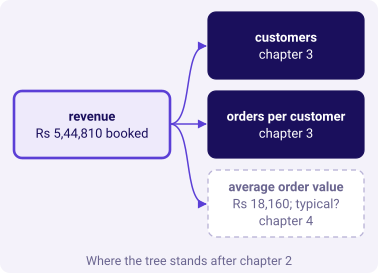

Next: chapter 3 counts the two customer branches from the rows.


In [9]:
kit.table(["What we now know", "The evidence"],
          [("Each branch is a numerator over a denominator on one definition", "AOV = Rs 5,44,810 / 30, about Rs 18,160"),
           ("Three branches are not in this file", "items, price and discounts"),
           ("A fraction from two definitions matches nothing", "Rs 25,943 would claim Rs 7,78,300")],
          caption="Chapter 2: what each branch is")
kit.driver_tree({"label": "revenue", "note": "Rs 5,44,810 booked", "kind": "known", "children": [
    {"label": "customers", "note": "chapter 3", "kind": "lit"},
    {"label": "orders per customer", "note": "chapter 3", "kind": "lit"},
    {"label": "average order value", "note": "Rs 18,160; typical? chapter 4", "kind": "unknown"}]},
    title="Where the tree stands after chapter 2")
kit.check_summary()
print("Next: chapter 3 counts the two customer branches from the rows.")